Задание 1 (4 балла)
1. Скачать данные по ссылке 
https://www.kaggle.com/datasets/dev0914sharma/customer-clustering/data
2. Провести кластерный анализ данных о клиентах;
3. Описать профиль всех полученных кластеров.

Результаты представить в формате .ipynb.


Первые 5 строк датасета о клиентах:
          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education  

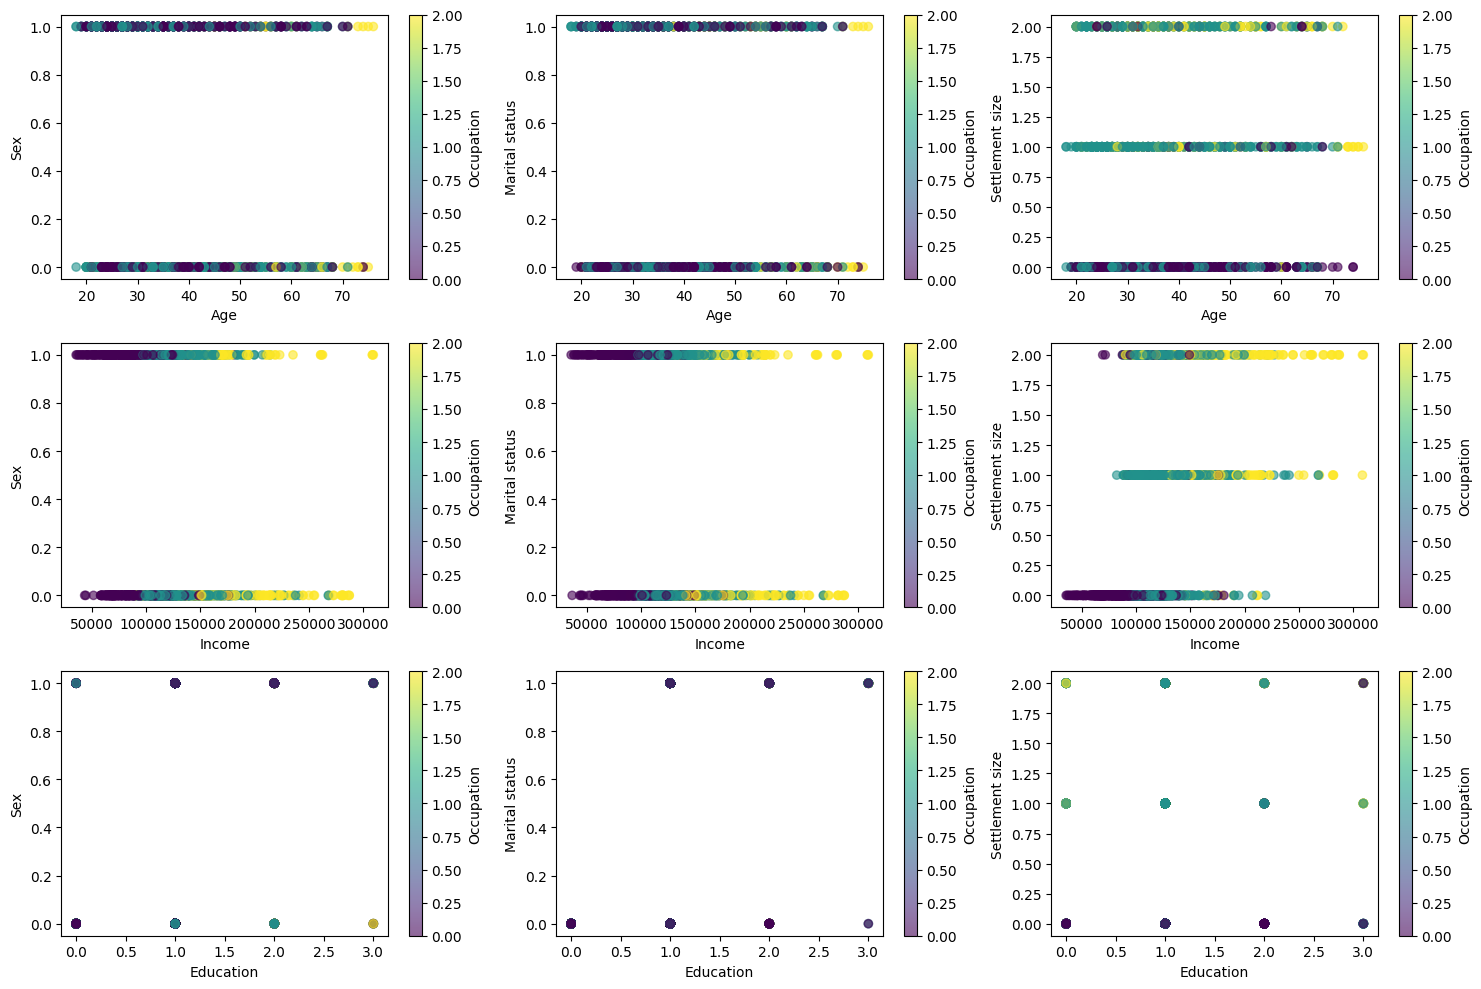

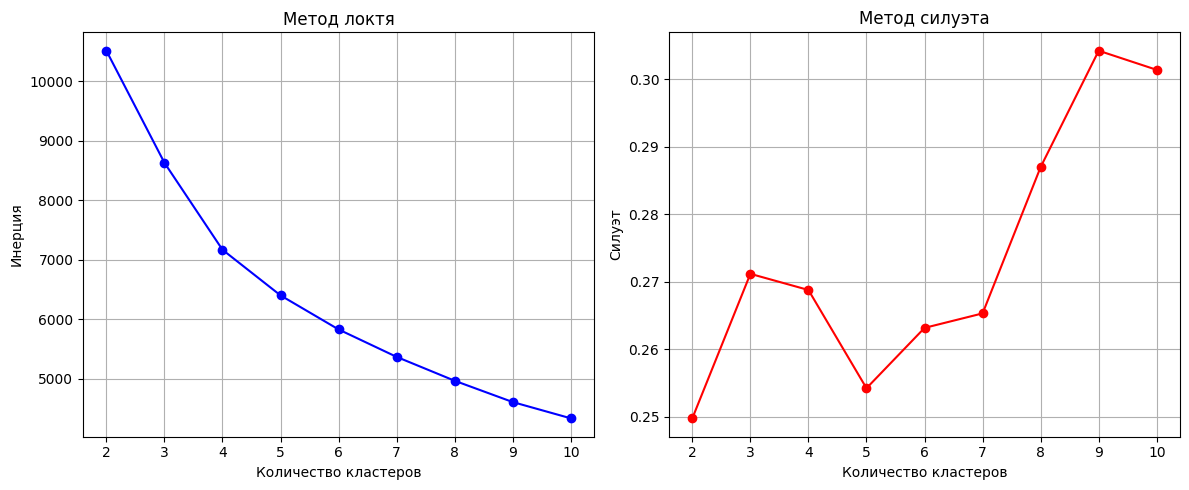


Оптимальное количество кластеров: 4


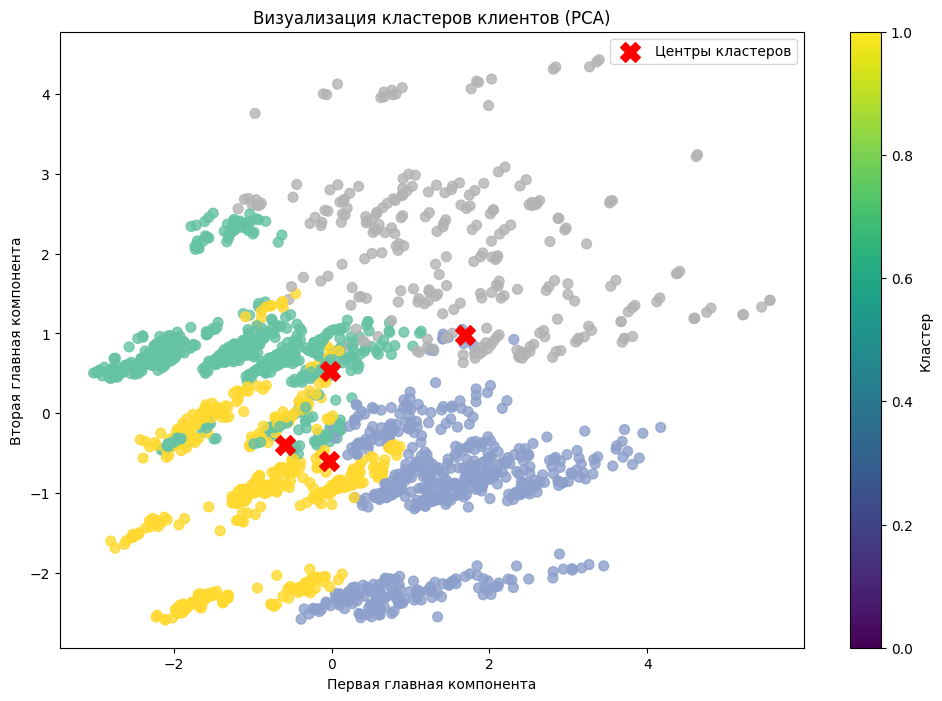

ПРОФИЛИ КЛАСТЕРОВ
          Age                  Income                              Sex  \
         mean   std min max      mean      std    min     max <lambda>   
Cluster                                                                  
0        29.0   6.8  18  59  105759.1  25370.3  35832  207262        1   
1        35.6   8.5  20  58  141218.2  33459.3  82398  268906        0   
2        35.6   8.7  19  68   97859.9  22950.8  36760  171857        0   
3        55.7  10.5  25  76  158338.4  46204.7  69487  309364        1   

        Marital status Education Occupation Settlement size  
              <lambda>  <lambda>   <lambda>        <lambda>  
Cluster                                                      
0                    1         1          1               0  
1                    0         1          1               2  
2                    0         1          0               0  
3                    1         2          1               1  


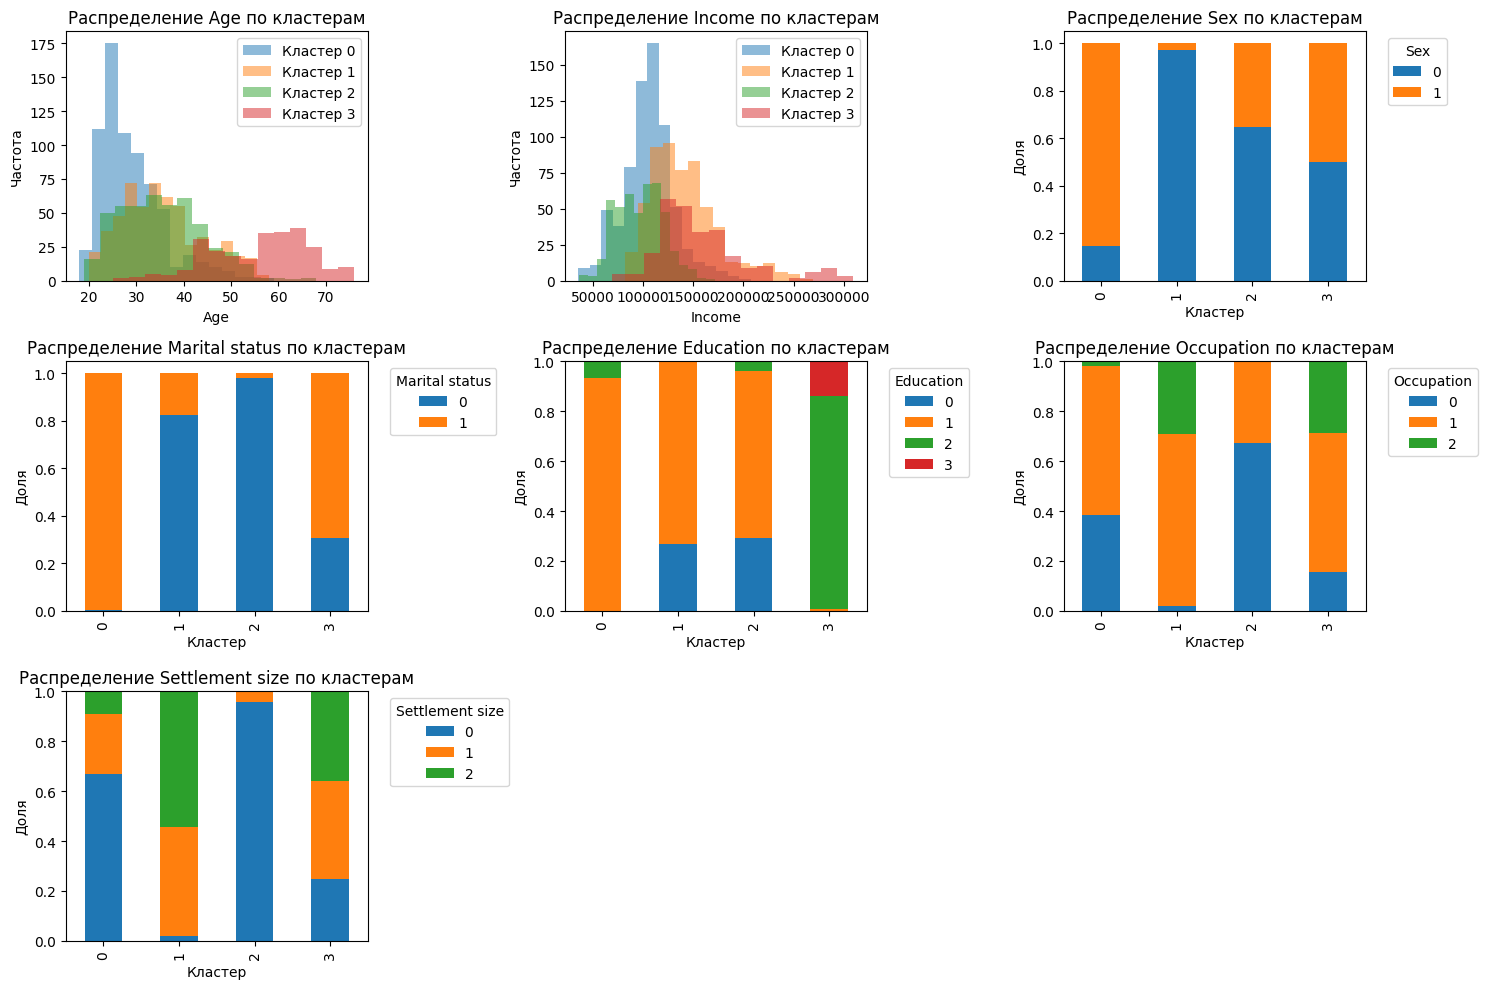

ДЕТАЛЬНОЕ ОПИСАНИЕ КЛАСТЕРОВ

КЛАСТЕР 0 (35.2% клиентов):
  Возраст: средний 29.0 лет (от 18 до 59)
  Доход: средний 105759.1 (от 35832 до 207262)
  Sex: преимущественно 1 (85.4%)
  Marital status: преимущественно 1 (99.7%)
  Education: преимущественно 1 (93.2%)
  Occupation: преимущественно 1 (59.7%)
  Settlement size: преимущественно 0 (66.8%)

КЛАСТЕР 1 (28.5% клиентов):
  Возраст: средний 35.6 лет (от 20 до 58)
  Доход: средний 141218.2 (от 82398 до 268906)
  Sex: преимущественно 0 (97.0%)
  Marital status: преимущественно 0 (82.6%)
  Education: преимущественно 1 (73.3%)
  Occupation: преимущественно 1 (68.9%)
  Settlement size: преимущественно 2 (54.2%)

КЛАСТЕР 2 (23.1% клиентов):
  Возраст: средний 35.6 лет (от 19 до 68)
  Доход: средний 97859.9 (от 36760 до 171857)
  Sex: преимущественно 0 (64.7%)
  Marital status: преимущественно 0 (98.1%)
  Education: преимущественно 1 (66.9%)
  Occupation: преимущественно 0 (67.1%)
  Settlement size: преимущественно 0 (95.7%)

КЛАСТЕР 3 (13.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('segmentation data.csv')
print("Первые 5 строк датасета о клиентах:")
print(df.head())
print("\nИнформация о датасете:")
print(df.info())
print("\nПропуски в данных:")
print(df.isnull().sum())
print("\nОписательная статистика:")
print(df.describe())

legend_df = pd.read_excel('segmentation data legend.xlsx')
print("\nЛегенда данных:")
print(legend_df)

categorical_cols = ['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']
print(f"\nКатегориальные признаки: {categorical_cols}")

df_encoded = df.copy()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\nКодирование {col}:")
    for original, encoded in zip(le.classes_, le.transform(le.classes_)):
        print(f"  {original} -> {encoded}")

features_for_clustering = ['Age', 'Income', 'Sex', 'Marital status', 'Education', 
                           'Occupation', 'Settlement size']
X = df_encoded[features_for_clustering].copy()

plt.figure(figsize=(15, 10))
for i, col1 in enumerate(['Age', 'Income', 'Education']):
    for j, col2 in enumerate(['Sex', 'Marital status', 'Settlement size']):
        plt.subplot(3, 3, i*3 + j + 1)
        scatter = plt.scatter(X[col1], X[col2], c=X['Occupation'], cmap='viridis', alpha=0.6)
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.colorbar(scatter, label='Occupation')
plt.tight_layout()
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция')
plt.title('Метод локтя')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Количество кластеров')
plt.ylabel('Силуэт')
plt.title('Метод силуэта')
plt.grid(True)
plt.tight_layout()
plt.show()

optimal_k = 4
print(f"\nОптимальное количество кластеров: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12, 8))
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='Set2', s=50, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='red', marker='X', label='Центры кластеров')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Визуализация кластеров клиентов (PCA)')
plt.colorbar(label='Кластер')
plt.legend()
plt.show()

print("ПРОФИЛИ КЛАСТЕРОВ")

cluster_profile = df.groupby('Cluster').agg({
    'Age': ['mean', 'std', 'min', 'max'],
    'Income': ['mean', 'std', 'min', 'max'],
    'Sex': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'Marital status': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'Education': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'Occupation': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'Settlement size': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
}).round(1)

print(cluster_profile)

plt.figure(figsize=(15, 10))
for i, feature in enumerate(['Age', 'Income', 'Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']):
    plt.subplot(3, 3, i+1)
    
    if feature in ['Age', 'Income']:
        for cluster in range(optimal_k):
            subset = df[df['Cluster'] == cluster]
            plt.hist(subset[feature], alpha=0.5, label=f'Кластер {cluster}', bins=15)
        plt.xlabel(feature)
        plt.ylabel('Частота')
        plt.legend()
    else:
        cross_tab = pd.crosstab(df['Cluster'], df[feature], normalize='index')
        cross_tab.plot(kind='bar', ax=plt.gca(), stacked=True)
        plt.xlabel('Кластер')
        plt.ylabel('Доля')
        plt.legend(title=feature, bbox_to_anchor=(1.05, 1))
    
    plt.title(f'Распределение {feature} по кластерам')
plt.tight_layout()
plt.show()

print("ДЕТАЛЬНОЕ ОПИСАНИЕ КЛАСТЕРОВ")

for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\nКЛАСТЕР {cluster} ({(len(cluster_data)/len(df)*100):.1f}% клиентов):")
    
    print(f"  Возраст: средний {cluster_data['Age'].mean():.1f} лет (от {cluster_data['Age'].min()} до {cluster_data['Age'].max()})")
    print(f"  Доход: средний {cluster_data['Income'].mean():.1f} (от {cluster_data['Income'].min()} до {cluster_data['Income'].max()})")
    
    for col in ['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']:
        mode_val = cluster_data[col].mode()[0]
        pct = (cluster_data[col] == mode_val).mean() * 100
        print(f"  {col}: преимущественно {mode_val} ({pct:.1f}%)")

print("ВЫВОДЫ")

silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
ch_score = calinski_harabasz_score(X_scaled, df['Cluster'])
db_score = davies_bouldin_score(X_scaled, df['Cluster'])

print(f"Качество кластеризации:")
print(f"  Силуэт: {silhouette_avg:.3f}")
print(f"  Индекс Калински-Харабаса: {ch_score:.1f}")
print(f"  Индекс Дэвиса-Болдина: {db_score:.3f}")

for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\nРекомендации для кластера {cluster}:")
    
    income_mean = cluster_data['Income'].mean()
    age_mean = cluster_data['Age'].mean()
    sex_mode = cluster_data['Sex'].mode()[0]
    edu_mode = cluster_data['Education'].mode()[0]
    occ_mode = cluster_data['Occupation'].mode()[0]
    
    if income_mean > df['Income'].mean():
        print("  • Высокодоходная группа - предлагать премиальные продукты")
    else:
        print("  • Среднедоходная группа - фокус на соотношение цена/качество")
    
    if age_mean < 35:
        print("  • Молодая аудитория - продвижение через соцсети и digital-каналы")
    elif age_mean > 50:
        print("  • Старшая аудитория - традиционные каналы коммуникации")
    
    if sex_mode == 0:
        print("  • Преобладают мужчины - учитывать гендерную специфику")
    else:
        print("  • Преобладают женщины - учитывать гендерную специфику")
    
    if edu_mode >= 3:
        print("  • Высокий уровень образования - информативные материалы")
    
    if occ_mode in [1, 2]:
        print("  • Офисные сотрудники - удобное время для коммуникации")